In [5]:
import pandas as pd


# path to the integrated MEDUSA dataset

RAW_PATH = '/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv'


# loading the dataset and applying the same cleaning used in the other scripts

df = pd.read_csv(RAW_PATH, low_memory=False)

id_col = (
    'MEDUSA_Subject_ID'
    if 'MEDUSA_Subject_ID' in df.columns
    else df.columns[0]
)


# some versions of the file store the real feature names
# in a MEDDESCRIPTION row rather than in the column headers

desc_mask = df[id_col].astype(str) == 'MEDDESCRIPTION'

if desc_mask.any():
    desc_row = df[desc_mask].iloc[0]

    rename_map = {
        c: desc_row[c]
        for c in df.columns
        if (
            c != id_col
            and pd.notna(desc_row[c])
            and desc_row[c] != c
        )
    }

    df = df.rename(columns=rename_map)

    print(
        f"Renamed {len(rename_map)} columns "
        "to their real feature names."
    )

else:
    print(
        "No MEDDESCRIPTION row found — "
        "assuming the file is already cleaned."
    )


# removing the extra feature-description rows before analysis

label_rows = df[id_col].astype(str).str.contains(
    'MEDDESCRIPTION|MEDFEATURE',
    na=False
)

if label_rows.any():
    print(
        f"Removing {label_rows.sum()} "
        "feature-description rows."
    )

    df = df[~label_rows].copy()


# converting mutation and copy-number features to numeric values

mutation_like = [
    c for c in df.columns
    if str(c).startswith(
        (
            'Mutation ',
            'Loss ',
            'Gain ',
            'DriverLoss',
            'DriverGain'
        )
    )
]

for c in mutation_like:
    df[c] = pd.to_numeric(
        df[c],
        errors='coerce'
    )


# converting the main clinical and molecular variables used below

for numeric_col in [
    'Age',
    'ageAcc.Horvath',
    'ScarHRD sum score',
    'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)',
    'Overall survival (Surgery-to-Death) in days'
]:
    if numeric_col in df.columns:
        df[numeric_col] = pd.to_numeric(
            df[numeric_col],
            errors='coerce'
        )


print(
    f"Loaded and cleaned: "
    f"{df.shape[0]} patients, "
    f"{df.shape[1]} columns.\n"
)


# using patients with available age data for the clinical summary

clin = df[df['Age'].notna()]


# Table A: patient characteristics

hist_map = {
    1.0: 'Group 1 (n=88, likely Epithelioid)',
    2.0: 'Group 2 (n=1, likely Sarcomatoid)',
    3.0: 'Group 3 (n=8, likely Biphasic)'
}

table_a_rows = []

table_a_rows.append({
    'Variable': 'Age (years)',
    'Summary': (
        f"Mean {clin['Age'].mean():.1f} "
        f"(SD {clin['Age'].std():.1f}), "
        f"range {clin['Age'].min():.0f}-"
        f"{clin['Age'].max():.0f}"
    ),
    'n': len(clin)
})


# adding histology counts

for label, count in (
    clin['Histology']
    .map(hist_map)
    .value_counts()
    .items()
):
    table_a_rows.append({
        'Variable': f'Histology: {label}',
        'Summary': f'n={count}',
        'n': count
    })


# adding gender counts

for label, count in (
    clin['Gender ']
    .map({1.0: 'Male', 2.0: 'Female'})
    .value_counts()
    .items()
):
    table_a_rows.append({
        'Variable': f'Gender: {label}',
        'Summary': f'n={count}',
        'n': count
    })


# adding stage counts

for label, count in (
    clin['IMIG Stage']
    .value_counts()
    .items()
):
    table_a_rows.append({
        'Variable': f'IMIG Stage: {label}',
        'Summary': f'n={count}',
        'n': count
    })


# adding asbestos-exposure counts

for label, count in (
    clin['Asbestos exposure']
    .value_counts(dropna=False)
    .items()
):
    table_a_rows.append({
        'Variable': f'Asbestos exposure: {label}',
        'Summary': f'n={count}',
        'n': count
    })


# adding smoking-status counts

for label, count in (
    clin['Smoking status']
    .value_counts(dropna=False)
    .items()
):
    table_a_rows.append({
        'Variable': f'Smoking status: {label}',
        'Summary': f'n={count}',
        'n': count
    })


pd.DataFrame(
    table_a_rows
).to_csv(
    'table_patient_characteristics.csv',
    index=False
)


# Table B: number of patients with data available for each modality

modalities = {
    'Clinical/pathological (Age, Histology, Stage)':
        df['Age'].notna().sum(),

    'Methylation (9 epigenetic clocks)':
        df['ageAcc.Horvath'].notna().sum(),

    'RNA-seq (ssGSEA hallmark pathways)':
        df['ssGSEA:HALLMARK_ADIPOGENESIS'].notna().sum(),

    'WES/genomic (mutation & SCNA calls)':
        df['Mutation BAP1'].notna().sum(),

    'HRD scores':
        df['ScarHRD sum score'].notna().sum(),

    'BAP1 IHC':
        df[
            'Overall BAP1 IHC '
            '(1=positive/retained, 0=negative/loss)'
        ].notna().sum(),

    'Overall survival data':
        df[
            'Overall survival '
            '(Surgery-to-Death) in days'
        ].notna().sum()
}


cohort_size = len(df)

pd.DataFrame([
    {
        'Data modality': modality,
        'n patients': count,
        f'% of cohort (n={cohort_size})':
            round(count / cohort_size * 100, 1)
    }
    for modality, count in modalities.items()
]).to_csv(
    'table_data_availability.csv',
    index=False
)


# Table C: number of variables within each feature category

categories = {
    'Methylation clocks (ageAcc)': [
        c for c in df.columns
        if c.startswith('ageAcc')
    ],

    'RNA-seq hallmark pathways (ssGSEA)': [
        c for c in df.columns
        if c.startswith('ssGSEA:')
    ],

    'Immune cell deconvolution': [
        c for c in df.columns
        if any(
            c.startswith(prefix)
            for prefix in [
                'ConsensusTME',
                'Cibersort',
                'xCell'
            ]
        )
    ],

    'Driver mutations': [
        c for c in df.columns
        if c.startswith('Mutation ')
    ],

    'Chromosome arm SCNA (Loss/Gain)': [
        c for c in df.columns
        if c.startswith(('Loss ', 'Gain '))
    ],

    'Driver SCNA / HRD / TMB': [
        c for c in df.columns
        if (
            c.startswith(
                (
                    'DriverLoss',
                    'DriverGain',
                    'ScarHRD'
                )
            )
            or 'TMB' in c
        )
    ],

    'Clinical/pathological': [
        'Age',
        'Gender ',
        'Histology',
        'pT stage',
        'p N stage',
        'IMIG Stage'
    ],

    'Survival/outcome': [
        c for c in df.columns
        if (
            'survival' in c.lower()
            or 'Status' in c
        )
    ]
}


pd.DataFrame([
    {
        'Data category': category,
        'n features': len(columns)
    }
    for category, columns in categories.items()
]).to_csv(
    'table_feature_categories.csv',
    index=False
)


print(
    "Saved 3 tables: "
    "table_patient_characteristics.csv, "
    "table_data_availability.csv, "
    "table_feature_categories.csv"
)

No MEDDESCRIPTION row found — assuming the file is already cleaned.
Loaded and cleaned: 235 patients, 1426 columns.

Saved 3 tables: table_patient_characteristics.csv, table_data_availability.csv, table_feature_categories.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# path to the final integrated MEDUSA dataset
RAW_PATH = '/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv'


# function for turning each CSV summary table into a PNG image
def make_table_png(csv_file, output_file, title, widths):
    table_df = pd.read_csv(csv_file)

    rows, columns = table_df.shape
    figure_height = 0.55 * (rows + 1) + 1.2
    figure_width = max(9, 2.2 * columns)

    fig, ax = plt.subplots(figsize=(figure_width, figure_height))
    ax.axis('off')

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='left',
        loc='center',
        colWidths=widths
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.7)

    # format the header and alternate the row shading
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor('lightgrey')

        if row == 0:
            cell.set_facecolor('steelblue')
            cell.set_text_props(
                color='white',
                fontweight='bold'
            )
        elif row % 2 == 0:
            cell.set_facecolor('whitesmoke')
        else:
            cell.set_facecolor('white')

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold',
        loc='left',
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.close()

    print(f'Saved {output_file}')


# load the ULTIMATE dataset
df = pd.read_csv(
    RAW_PATH,
    low_memory=False
)

id_col = (
    'MEDUSA_Subject_ID'
    if 'MEDUSA_Subject_ID' in df.columns
    else df.columns[0]
)


# check whether the file still contains the metadata rows
description_mask = (
    df[id_col].astype(str) == 'MEDDESCRIPTION'
)

if description_mask.any():

    print(
        'MEDDESCRIPTION row found, so the file will be cleaned first.'
    )

    description_row = df[description_mask].iloc[0]

    # use the description row as the proper feature names
    rename_map = {
        column: description_row[column]
        for column in df.columns
        if (
            column != id_col
            and pd.notna(description_row[column])
            and description_row[column] != column
        )
    }

    df = df.rename(columns=rename_map)

    # remove the metadata rows before counting patients
    label_rows = (
        df[id_col]
        .astype(str)
        .str.contains(
            'MEDDESCRIPTION|MEDFEATURE',
            na=False
        )
    )

    df = df[~label_rows].copy()

else:

    print(
        'No MEDDESCRIPTION row found; assuming the file is already cleaned.'
    )


# convert mutation and copy-number columns to numeric values
mutation_like = [
    column
    for column in df.columns
    if str(column).startswith(
        (
            'Mutation ',
            'Loss ',
            'Gain ',
            'DriverLoss',
            'DriverGain'
        )
    )
]

for column in mutation_like:
    df[column] = pd.to_numeric(
        df[column],
        errors='coerce'
    )


# convert the main variables used in the summary tables
numeric_columns = [
    'Age',
    'Histology',
    'Gender ',
    'ageAcc.Horvath',
    'ScarHRD sum score',
    'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)',
    'Overall survival (Surgery-to-Death) in days'
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors='coerce'
        )


total_patients = len(df)

print(
    f'Loaded: {total_patients} patients '
    f'and {df.shape[1]} columns.\n'
)


# patients with clinical information
clinical_df = df[df['Age'].notna()].copy()


# Table 1: patient characteristics
histology_map = {
    1.0: 'Epithelioid',
    2.0: 'Sarcomatoid',
    3.0: 'Biphasic'
}

gender_map = {
    1.0: 'Male',
    2.0: 'Female'
}

table_1_rows = []

table_1_rows.append({
    'Variable': 'Age (years)',
    'Summary': (
        f"Mean {clinical_df['Age'].mean():.1f} "
        f"(SD {clinical_df['Age'].std():.1f}), "
        f"range {clinical_df['Age'].min():.0f}–"
        f"{clinical_df['Age'].max():.0f}"
    ),
    'n': len(clinical_df)
})


# histology counts
for label, count in (
    clinical_df['Histology']
    .map(histology_map)
    .value_counts()
    .items()
):
    table_1_rows.append({
        'Variable': f'Histology: {label}',
        'Summary': f'n = {count}',
        'n': count
    })


# gender counts
for label, count in (
    clinical_df['Gender ']
    .map(gender_map)
    .value_counts()
    .items()
):
    table_1_rows.append({
        'Variable': f'Gender: {label}',
        'Summary': f'n = {count}',
        'n': count
    })


# stage counts
for label, count in (
    clinical_df['IMIG Stage']
    .value_counts()
    .items()
):
    table_1_rows.append({
        'Variable': f'IMIG stage: {label}',
        'Summary': f'n = {count}',
        'n': count
    })


# asbestos exposure counts
for label, count in (
    clinical_df['Asbestos exposure']
    .value_counts(dropna=False)
    .items()
):
    table_1_rows.append({
        'Variable': f'Asbestos exposure: {label}',
        'Summary': f'n = {count}',
        'n': count
    })


# smoking status counts
for label, count in (
    clinical_df['Smoking status']
    .value_counts(dropna=False)
    .items()
):
    table_1_rows.append({
        'Variable': f'Smoking status: {label}',
        'Summary': f'n = {count}',
        'n': count
    })


table_1 = pd.DataFrame(table_1_rows)

table_1.to_csv(
    'table_patient_characteristics.csv',
    index=False
)


# Table 2: data availability by modality
modalities = {
    'Clinical/pathological (Age, Histology, Stage)':
        df['Age'].notna().sum(),

    'Methylation (9 epigenetic clocks)':
        df['ageAcc.Horvath'].notna().sum(),

    'RNA-seq (ssGSEA hallmark pathways)':
        df['ssGSEA:HALLMARK_ADIPOGENESIS'].notna().sum(),

    'WES/genomic (mutation and SCNA calls)':
        df['Mutation BAP1'].notna().sum(),

    'HRD scores':
        df['ScarHRD sum score'].notna().sum(),

    'BAP1 IHC':
        df[
            'Overall BAP1 IHC '
            '(1=positive/retained, 0=negative/loss)'
        ].notna().sum(),

    'Overall survival data':
        df[
            'Overall survival '
            '(Surgery-to-Death) in days'
        ].notna().sum()
}


# add the spatial data subsets if those columns are present
if 'Has_Spatial_Protein_Data' in df.columns:
    modalities['Spatial protein profiling (GeoMx subset)'] = int(
        pd.to_numeric(
            df['Has_Spatial_Protein_Data'],
            errors='coerce'
        )
        .fillna(0)
        .sum()
    )

if 'Has_Spatial_RNA_Data' in df.columns:
    modalities['Spatial transcriptomic profiling (GeoMx subset)'] = int(
        pd.to_numeric(
            df['Has_Spatial_RNA_Data'],
            errors='coerce'
        )
        .fillna(0)
        .sum()
    )


table_2 = pd.DataFrame([
    {
        'Data modality': modality,
        'n patients': int(count),
        f'% of cohort (n={total_patients})':
            round(count / total_patients * 100, 1)
    }
    for modality, count in modalities.items()
])

table_2.to_csv(
    'table_data_availability.csv',
    index=False
)


# Table 3: feature counts by category
categories = {

    'Methylation clocks (ageAcc)': [
        column
        for column in df.columns
        if column.startswith('ageAcc')
    ],

    'RNA-seq hallmark pathways (ssGSEA)': [
        column
        for column in df.columns
        if column.startswith('ssGSEA:')
    ],

    'Immune cell deconvolution': [
        column
        for column in df.columns
        if any(
            column.startswith(prefix)
            for prefix in [
                'ConsensusTME',
                'Cibersort',
                'xCell'
            ]
        )
    ],

    'Driver mutations': [
        column
        for column in df.columns
        if column.startswith('Mutation ')
    ],

    'Chromosome arm SCNA (Loss/Gain)': [
        column
        for column in df.columns
        if column.startswith(
            (
                'Loss ',
                'Gain '
            )
        )
    ],

    'Driver SCNA / HRD / TMB': [
        column
        for column in df.columns
        if (
            column.startswith(
                (
                    'DriverLoss',
                    'DriverGain',
                    'ScarHRD'
                )
            )
            or 'TMB' in column
        )
    ],

    'Clinical/pathological': [
        column
        for column in [
            'Age',
            'Gender ',
            'Histology',
            'pT stage',
            'p N stage',
            'IMIG Stage'
        ]
        if column in df.columns
    ],

    'Survival/outcome': [
        column
        for column in df.columns
        if (
            'survival' in column.lower()
            or 'status' in column.lower()
        )
    ],

    'Spatial protein profiling (GeoMx)': [
        column
        for column in df.columns
        if column.startswith('GeoMxProtein:')
    ]
}


table_3 = pd.DataFrame([
    {
        'Data category': category,
        'n features': len(columns)
    }
    for category, columns in categories.items()
])

table_3.to_csv(
    'table_feature_categories.csv',
    index=False
)


print(
    'Saved the three CSV summary tables.'
)


# create the PNG version of Table 1
make_table_png(
    'table_patient_characteristics.csv',
    'table_patient_characteristics.png',
    title=(
        'Patient characteristics '
        f'(n={len(clinical_df)} with clinical/pathological data)'
    ),
    widths=[0.48, 0.40, 0.12]
)


# create the PNG version of Table 2
make_table_png(
        'table_data_availability.csv',
    'table_data_availability.png',
    title=(
        f'Data availability by modality '
        f'(n={total_patients} total MEDUSA patients)'
    ),
    widths=[0.58, 0.21, 0.21]
)


# create the PNG version of Table 3
make_table_png(
    'table_feature_categories.csv',
    'table_feature_categories.png',
    title='Feature counts by data category',
    widths=[0.78, 0.22]
)


print(
    '\nFinished creating all CSV and PNG tables.'
)

No MEDDESCRIPTION row found; assuming the file is already cleaned.
Loaded: 235 patients and 1426 columns.

Saved the three CSV summary tables.
Saved table_patient_characteristics.png
Saved table_data_availability.png
Saved table_feature_categories.png

Finished creating all CSV and PNG tables.


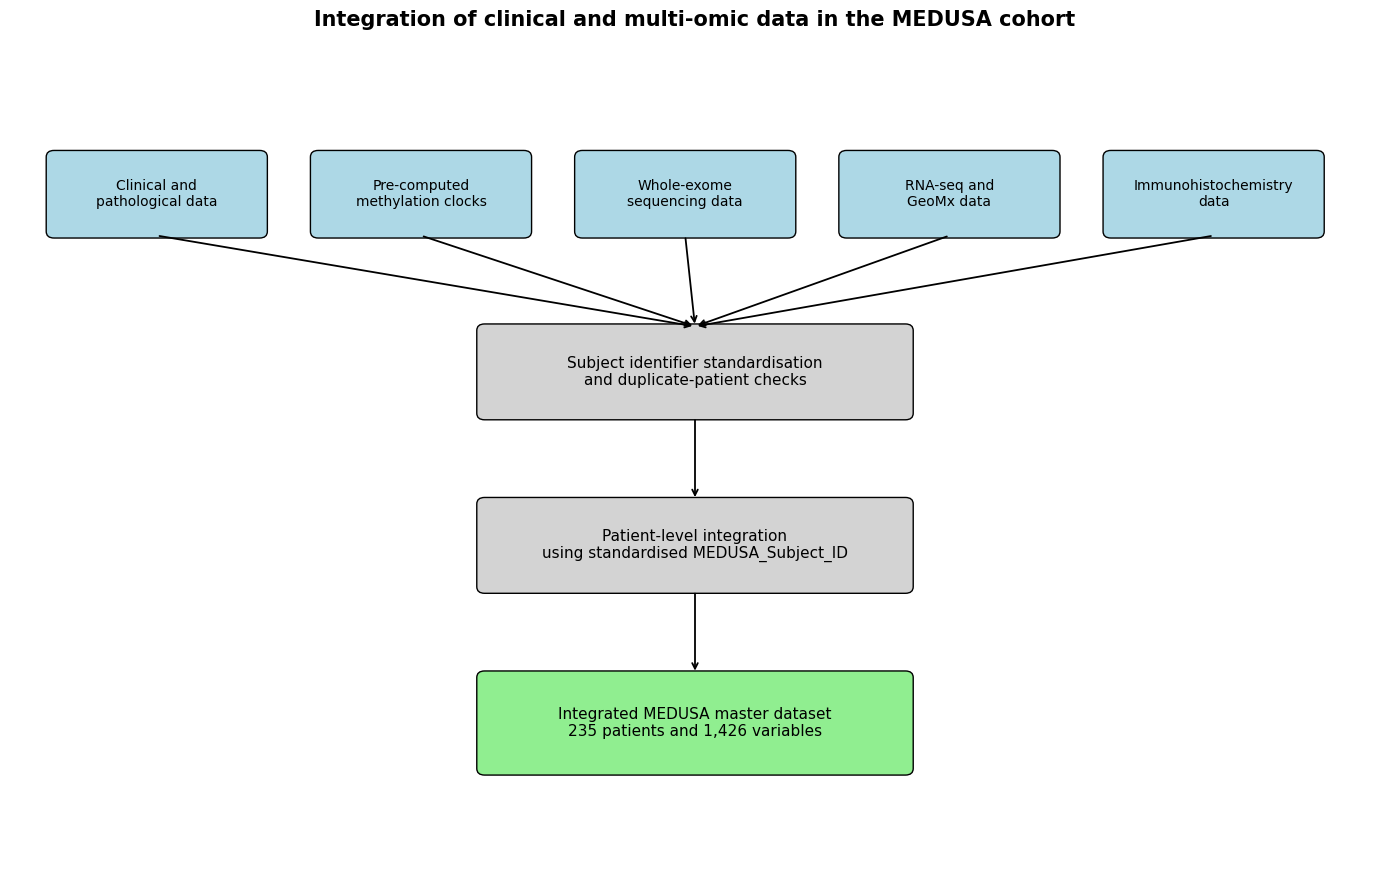

Saved /home/rt334/Independent/Hermes/MEDUSA_figures/figure_medusa_integration_workflow.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path


# folder where I want the finished figure saved
OUTPUT_DIR = Path("/home/rt334/Independent/Hermes/MEDUSA_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Figure 3: MEDUSA data integration workflow

fig, ax = plt.subplots(figsize=(14, 9))

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')


# adding a rounded box to the workflow

def add_box(
    ax,
    x,
    y,
    width,
    height,
    text,
    facecolour='whitesmoke',
    fontsize=10
):
    box = patches.FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.03,rounding_size=0.08',
        facecolor=facecolour,
        edgecolor='black',
        linewidth=1.0
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha='center',
        va='center',
        fontsize=fontsize
    )

    return box


# adding an arrow between workflow stages

def add_arrow(
    ax,
    start_x,
    start_y,
    end_x,
    end_y
):
    ax.annotate(
        '',
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops={
            'arrowstyle': '->',
            'linewidth': 1.3,
            'color': 'black'
        }
    )


# source datasets used to build the integrated dataset

source_width = 2.2
source_height = 1.0
source_y = 7.8

source_boxes = [
    (0.4, 'Clinical and\npathological data'),
    (3.1, 'Pre-computed\nmethylation clocks'),
    (5.8, 'Whole-exome\nsequencing data'),
    (8.5, 'RNA-seq and\nGeoMx data'),
    (11.2, 'Immunohistochemistry\ndata')
]

for x_position, label in source_boxes:
    add_box(
        ax,
        x=x_position,
        y=source_y,
        width=source_width,
        height=source_height,
        text=label,
        facecolour='lightblue'
    )


# subject identifier standardisation

standardisation_x = 4.8
standardisation_y = 5.6
standardisation_width = 4.4
standardisation_height = 1.1

add_box(
    ax,
    x=standardisation_x,
    y=standardisation_y,
    width=standardisation_width,
    height=standardisation_height,
    text=(
        'Subject identifier standardisation\n'
        'and duplicate-patient checks'
    ),
    facecolour='lightgrey',
    fontsize=11
)


# linking each source dataset to the standardisation stage

for x_position, _ in source_boxes:
    source_centre_x = x_position + source_width / 2

    add_arrow(
        ax,
        start_x=source_centre_x,
        start_y=source_y,
        end_x=7.0,
        end_y=standardisation_y + standardisation_height
    )


# patient-level dataset integration

integration_x = 4.8
integration_y = 3.5
integration_width = 4.4
integration_height = 1.1

add_box(
    ax,
    x=integration_x,
    y=integration_y,
    width=integration_width,
    height=integration_height,
    text=(
        'Patient-level integration\n'
        'using standardised MEDUSA_Subject_ID'
    ),
    facecolour='lightgrey',
    fontsize=11
)

add_arrow(
    ax,
    start_x=7.0,
    start_y=standardisation_y,
    end_x=7.0,
    end_y=integration_y + integration_height
)


# final integrated MEDUSA dataset

master_x = 4.8
master_y = 1.3
master_width = 4.4
master_height = 1.2

add_box(
    ax,
    x=master_x,
    y=master_y,
    width=master_width,
    height=master_height,
    text=(
        'Integrated MEDUSA master dataset\n'
        '235 patients and 1,426 variables'
    ),
    facecolour='lightgreen',
    fontsize=11
)

add_arrow(
    ax,
    start_x=7.0,
    start_y=integration_y,
    end_x=7.0,
    end_y=master_y + master_height
)


# adding the figure title

ax.set_title(
    'Integration of clinical and multi-omic data in the MEDUSA cohort',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.tight_layout()


# saving the workflow figure in the same output folder as the tables

workflow_file = (
    OUTPUT_DIR /
    'figure_medusa_integration_workflow.png'
)

plt.savefig(
    workflow_file,
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print(f'Saved {workflow_file}')

In [9]:
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def run_final_hypothesis_test(file_path):

    print(f'--- MTAP vs ssGSEA pathways: {file_path} ---')

    # loading the integrated MEDUSA dataset
    df = pd.read_csv(file_path, low_memory=False)


    # finding the 9p21 loss variable used as the MTAP-loss indicator
    preferred_column = 'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)'

    if preferred_column in df.columns:
        driver_col = preferred_column
    else:
        potential_cols = [
            column
            for column in df.columns
            if (
                '9P21' in str(column).upper()
                or 'MTAP' in str(column).upper()
            )
        ]

        if not potential_cols:
            raise ValueError(
                'Could not find a suitable MTAP/9p21 column. '
                'Check the column names in the dataset.'
            )

        driver_col = potential_cols[0]

        if len(potential_cols) > 1:
            print(
                'Multiple possible MTAP/9p21 columns were found: '
                f'{potential_cols}'
            )
            print(f'Using: {driver_col}')

    print(f'Driver column selected: {driver_col}')


    # converting the group variable to numeric and keeping valid binary values
    df[driver_col] = pd.to_numeric(
        df[driver_col],
        errors='coerce'
    )

    df_clean = df[
        df[driver_col].isin([0.0, 1.0])
    ].copy()

    group_loss = df_clean[
        df_clean[driver_col] == 1.0
    ]

    group_intact = df_clean[
        df_clean[driver_col] == 0.0
    ]

    print(f'Group size (MTAP loss): {len(group_loss)}')
    print(f'Group size (MTAP intact): {len(group_intact)}')

    if group_loss.empty or group_intact.empty:
        raise ValueError(
            'One of the MTAP groups is empty after filtering.'
        )


    # identifying the RNA-seq hallmark pathway columns
    pathway_cols = [
        column
        for column in df.columns
        if str(column).startswith('ssGSEA:')
    ]

    print(
        f'Found {len(pathway_cols)} '
        'ssGSEA pathway columns to test.\n'
    )


    # comparing each pathway between MTAP-loss and MTAP-intact tumours
    results = []

    for pathway in pathway_cols:

        scores_loss = pd.to_numeric(
            group_loss[pathway],
            errors='coerce'
        ).dropna()

        scores_intact = pd.to_numeric(
            group_intact[pathway],
            errors='coerce'
        ).dropna()

        # skipping comparisons with too few available patients
        if len(scores_loss) < 3 or len(scores_intact) < 3:
            continue

        statistic, p_value = mannwhitneyu(
            scores_loss,
            scores_intact,
            alternative='two-sided'
        )

        # positive values indicate a higher median in the MTAP-loss group
        median_difference = (
            scores_loss.median()
            - scores_intact.median()
        )

        results.append({
            'Pathway': pathway.replace('ssGSEA:', ''),
            'n (loss)': len(scores_loss),
            'n (intact)': len(scores_intact),
            'Median difference (loss - intact)': median_difference,
            'U statistic': statistic,
            'p-value': p_value
        })


    results_df = pd.DataFrame(results)

    if results_df.empty:
        print('No pathway comparisons met the inclusion criteria.')
        return results_df


    # correcting for the number of pathways tested
    results_df['FDR'] = multipletests(
        results_df['p-value'],
        method='fdr_bh'
    )[1]

    results_df = results_df.sort_values(
        'p-value'
    ).reset_index(drop=True)


    # rounding only the copy used for display and saving
    output_df = results_df.copy()

    output_df[
        'Median difference (loss - intact)'
    ] = output_df[
        'Median difference (loss - intact)'
    ].round(4)

    output_df['U statistic'] = (
        output_df['U statistic'].round(1)
    )

    output_df['p-value'] = (
        output_df['p-value'].round(4)
    )

    output_df['FDR'] = (
        output_df['FDR'].round(4)
    )


    print('=' * 80)
    print(
        'MTAP-associated hallmark pathway analysis '
        '(Mann–Whitney U tests with FDR correction)'
    )
    print('=' * 80)

    print(
        output_df.to_string(index=False)
    )

    print('=' * 80)

    print(
        f'Total pathways tested: {len(results_df)}'
    )

    print(
        'Nominally significant (p < 0.05): '
        f"{(results_df['p-value'] < 0.05).sum()}"
    )

    print(
        'Significant after FDR correction (FDR < 0.05): '
        f"{(results_df['FDR'] < 0.05).sum()}"
    )


    output_df.to_csv(
        'table_mtap_vs_pathways.csv',
        index=False
    )

    print('\nSaved table_mtap_vs_pathways.csv')

    return results_df


if __name__ == '__main__':

    DATASET_PATH = (
        '/home/rt334/Downloads/'
        'MEDUSA_Master_ULTIMATE.csv'
    )

    run_final_hypothesis_test(DATASET_PATH)

--- MTAP vs ssGSEA pathways: /home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv ---
Driver column selected: DriverLoss 9p21 (CDKN2A,MTAP,IFNA)
Group size (MTAP loss): 80
Group size (MTAP intact): 56
Found 50 ssGSEA pathway columns to test.

MTAP-associated hallmark pathway analysis (Mann–Whitney U tests with FDR correction)
                                   Pathway  n (loss)  n (intact)  Median difference (loss - intact)  U statistic  p-value    FDR
                   HALLMARK_G2M_CHECKPOINT        70          46                             0.0146       2187.5   0.0011 0.0564
                 HALLMARK_MTORC1_SIGNALING        70          46                             0.0065       2127.0   0.0036 0.0861
                      HALLMARK_E2F_TARGETS        70          46                             0.0159       2106.0   0.0052 0.0861
                  HALLMARK_MITOTIC_SPINDLE        70          46                             0.0066       2076.0   0.0086 0.1076
                   HALLMARK_MYC